In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline
import yfinance as yf 

#pip install yfinance


In [4]:
assets = ["PG", "^GSPC"]
data = yf.download(assets, start = "2010-01-01")
data["Close"].tail(5)

[*********************100%***********************]  2 of 2 completed


Ticker,PG,^GSPC
Date,,
2026-05-04,143.419998,7200.750000
2026-05-05,144.899994,7259.220215
2026-05-06,147.899994,7365.120117
2026-05-07,146.059998,7337.109863
2026-05-08,146.419998,7398.930176


In [11]:
# Normalizing the data 

normalize = (data / data.iloc[0] * 100)
normalize["Close"].tail(5)


Ticker,PG,^GSPC
Date,,
2026-05-04,378.805766,635.552835
2026-05-05,382.714781,640.713535
2026-05-06,390.638483,650.060475
2026-05-07,385.778622,647.588233
2026-05-08,386.729468,653.044620


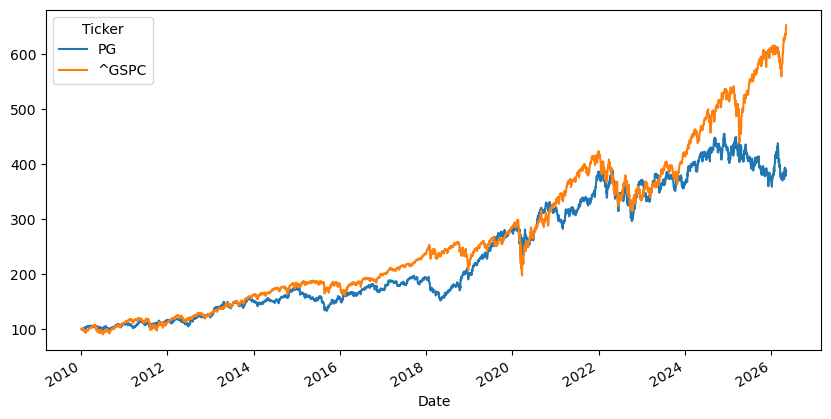

In [14]:
normalize["Close"].plot(figsize = (10,5)) 
plt.show()

In [17]:
log_returns = np.log(data["Close"] / data["Close"].shift(1))

                     
                     

In [18]:
log_returns.mean() *250

Ticker
PG       0.082252
^GSPC    0.114113
dtype: float64

In [20]:
log_returns.cov() * 250 

Ticker,PG,^GSPC
Ticker,,
PG,0.029693,0.014872
^GSPC,0.014872,0.029711


In [22]:
log_returns.corr()

Ticker,PG,^GSPC
Ticker,,
PG,1.000000,0.500723
^GSPC,0.500723,1.000000


In [27]:
#weights allocation 

weights = np.random.random(len(assets))
weights /= np.sum(weights)
weights

array([0.54077575, 0.45922425])

In [28]:
weights[0] + weights[1]

np.float64(1.0)

In [30]:
# Expected Portfolio Return 
np.sum(weights * log_returns.mean())* 250 

np.float64(0.09688348405650025)

In [41]:
# Expected Portfolio Variance 
var = np.dot(weights.T, np.dot(log_returns.cov() * 250, weights))
var


np.float64(0.022335590679759407)

In [43]:
# Expected Portfolio Volatility 
vol = np.dot(weights.T, np.dot(log_returns.cov() * 250, weights)) ** 0.5
vol



np.float64(0.14945096413124742)

In [72]:
pfolio_returns = []
pfolio_volatility = []
pfolio_weights = []

for x in range(1000):
    weights = np.random.random(len(assets))
    weights /= np.sum(weights)

    pfolio_returns.append(np.sum(weights * log_returns.mean()) * 250)

    pfolio_volatility.append(
        np.dot(weights.T, np.dot(log_returns.cov() * 250, weights)) ** 0.5
    )

    pfolio_weights.append(weights)

p_returns = np.array(pfolio_returns)
p_vol = np.array(pfolio_volatility)
p_weights = np.array(pfolio_weights)

p_returns, p_vol, p_weights

(array([0.09707595, 0.09912498, 0.09302559, 0.09293416, 0.09919948,
        0.11252892, 0.10924447, 0.10552949, 0.08250761, 0.09393438,
        0.09799937, 0.08951198, 0.10108612, 0.0949727 , 0.09330464,
        0.10668145, 0.1117758 , 0.09537396, 0.10077365, 0.0833237 ,
        0.10142323, 0.09811788, 0.09957116, 0.10305527, 0.0996659 ,
        0.10669867, 0.10275748, 0.0931085 , 0.10976428, 0.09933454,
        0.10259199, 0.08413865, 0.11054866, 0.09749371, 0.1102534 ,
        0.11161359, 0.09346624, 0.10408934, 0.10356416, 0.09647804,
        0.10124229, 0.10549107, 0.09623646, 0.09487209, 0.11373607,
        0.0928865 , 0.09936216, 0.10567073, 0.09735457, 0.09144481,
        0.09615889, 0.10181498, 0.10397727, 0.09906885, 0.10067156,
        0.11026609, 0.10704341, 0.09677986, 0.09756662, 0.08831202,
        0.09578141, 0.09296417, 0.10889183, 0.10472813, 0.09806757,
        0.11259609, 0.09627706, 0.09641912, 0.095349  , 0.09132086,
        0.10393455, 0.10651226, 0.10387601, 0.09

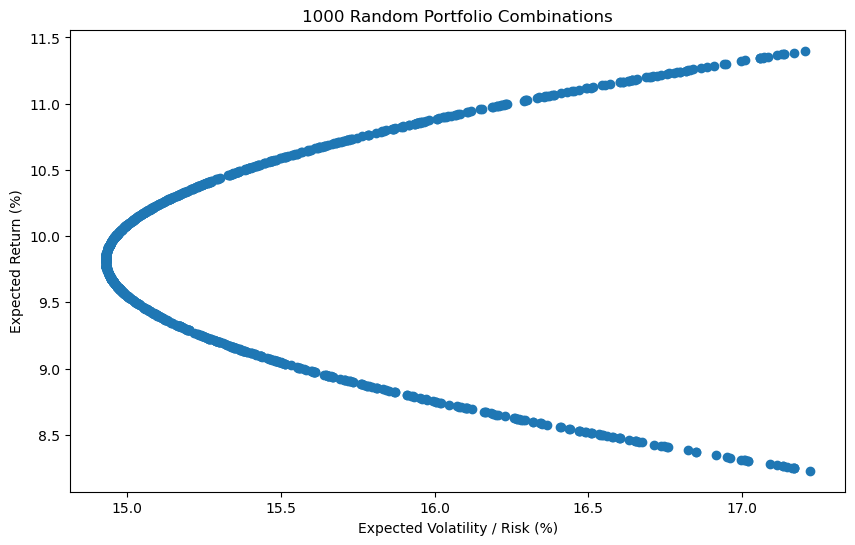

In [73]:
plt.figure(figsize=(10, 6))

plt.scatter(p_vol * 100, p_returns * 100)

plt.xlabel("Expected Volatility / Risk (%)")
plt.ylabel("Expected Return (%)")
plt.title("1000 Random Portfolio Combinations")

plt.show()

In [74]:
sharpe_ratios = p_returns / p_vol
best_index = sharpe_ratios.argmax()
best_index

np.int64(160)

In [75]:
best_return = p_returns[best_index]
best_volatility = p_vol[best_index]
best_sharpe = sharpe_ratios[best_index]
best_weights = p_weights[best_index]

print("Best Portfolio Index:", best_index)
print("Best Expected Return:", round(best_return * 100, 2), "%")
print("Best Volatility/Risk:", round(best_volatility * 100, 2), "%")
print("Best Sharpe Ratio:", round(best_sharpe, 3))
print("Best Weights:")
for asset, weight in zip(assets, best_weights):
    print(asset, ":", round(weight * 100, 2), "%")

Best Portfolio Index: 160
Best Expected Return: 10.6 %
Best Volatility/Risk: 15.51 %
Best Sharpe Ratio: 0.683
Best Weights:
PG : 25.6 %
^GSPC : 74.4 %


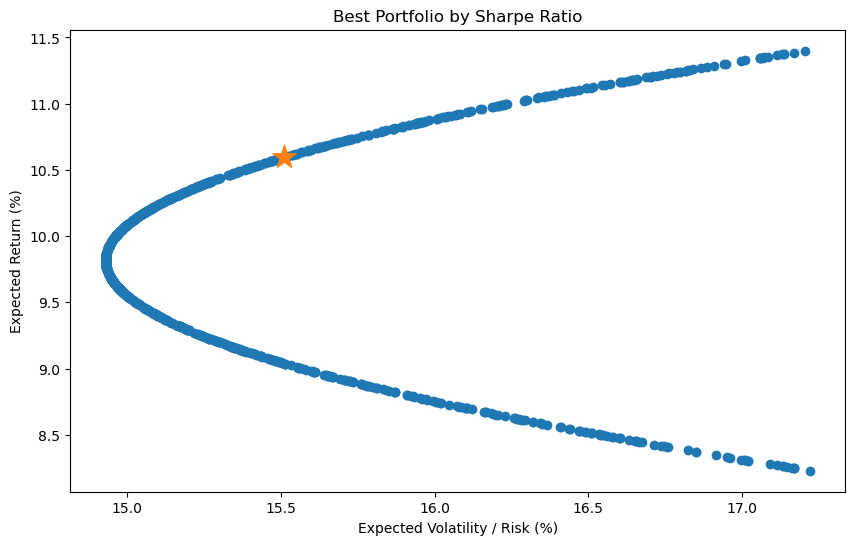

In [76]:
plt.figure(figsize=(10, 6))

plt.scatter(p_vol * 100, p_returns * 100)
plt.scatter(best_volatility * 100, best_return * 100, marker="*", s=300)

plt.xlabel("Expected Volatility / Risk (%)")
plt.ylabel("Expected Return (%)")
plt.title("Best Portfolio by Sharpe Ratio")

plt.show()